# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset.

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [128]:
from tensorflow.keras.datasets import fashion_mnist

#  X_train - image, y_train - label

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

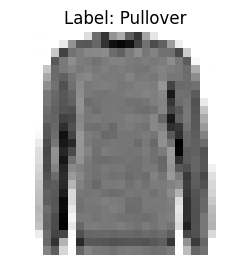

In [129]:
import matplotlib.pyplot as plt

sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(X_train[sample_index], cmap=plt.cm.gray_r, interpolation='nearest')
plt.title(f"Label: {class_names[y_train[sample_index]]}")
plt.axis('off')
plt.show()


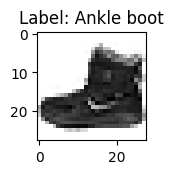

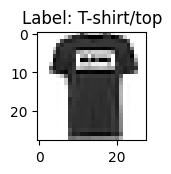

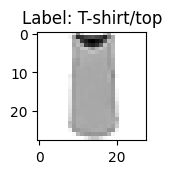

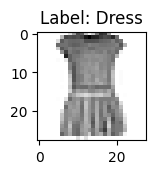

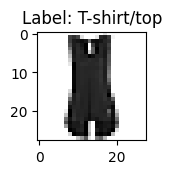

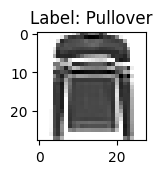

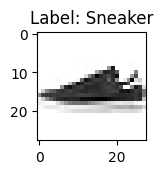

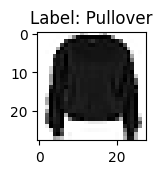

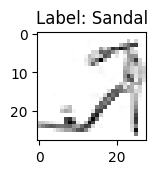

In [130]:
for i in range(9):
  plt.subplot(3, 3, i + 1)
  plt.imshow(X_train[i], cmap=plt.cm.gray_r)
  plt.title(f'Label: {class_names[y_train[i]]}')
  plt.show()

In [131]:
# Inspect the shapes of the datasets

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [132]:
# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [133]:
import matplotlib.pyplot as plt
# Verify the data looks as expected

y_train.shape

(60000, 10)

In [134]:
y_test.shape

(10000, 10)

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

The data structure appears well-organized, with each image paired with a corresponding label from ten distinct classes. However, the grayscale images are relatively low-resolution (28×28 pixels), which can make some items appear visually ambiguous or hard to distinguish—especially between similar categories like shirts and T-shirts. This limited clarity is expected given the dataset's simplicity.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [135]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input, Dropout
from tensorflow.keras import layers

# Create a simple linear regression model
model = Sequential()

# You can use `model.add(<layer>)` to add layers to the model

model.add(Flatten())
model.add(Dense(10,))
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [136]:
# Compile the model using `model.compile()`

model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [137]:

# Train the model with `model.fit()`

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)



Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1083 - loss: 8.1044 - val_accuracy: 0.1880 - val_loss: 10.3353
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1852 - loss: 10.1559 - val_accuracy: 0.1880 - val_loss: 9.8593
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1867 - loss: 9.7978 - val_accuracy: 0.1880 - val_loss: 9.7329
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1866 - loss: 9.7332 - val_accuracy: 0.1880 - val_loss: 9.6267
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1859 - loss: 9.5592 - val_accuracy: 0.1880 - val_loss: 9.5461
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1889 - loss: 9.5642 - val_accuracy: 0.1880 - val_loss: 9.5501
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1870 - loss: 9.5376 - val_accuracy: 0.1880 - val_loss: 9.4936
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1878 - loss: 9.4711 

In [138]:
# Evaluate the model with `model.evaluate()`

loss, accuracy = model.evaluate(X_test, y_test)

print(f'Lost: {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1830 - loss: 9.4101
Lost: 9.41
Accuracy: 18.55


/tmp/ipython-input-1594842500.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


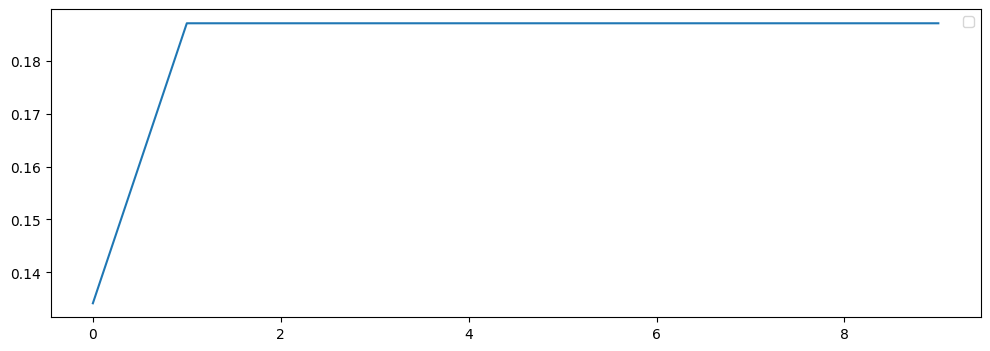

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(history.history['accuracy'])
plt.legend()

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

The baseline model showed low initial performance due to its limited capacity and lack of nonlinear layers, and its accuracy stayed the same over epochs likely due to underfitting and inability to generalize complex patterns in the data. The model is too simple to capture the complexity of this dataset, therefore leading to poor performace and accuracy.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [140]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model

model_2 = Sequential()

model_2.add(Conv2D(32, 3, activation='relu'))
model_2.add(Flatten())
model_2.add(Dense(10, activation='softmax'))
model_2.summary()


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [141]:
# Train the model
model_2.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [142]:
# Evaluate the model
history = model_2.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6971 - loss: 0.9107 - val_accuracy: 0.8039 - val_loss: 0.5698
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8187 - loss: 0.5184 - val_accuracy: 0.8331 - val_loss: 0.4750
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8385 - loss: 0.4743 - val_accuracy: 0.8419 - val_loss: 0.4589
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8422 - loss: 0.4563 - val_accuracy: 0.8421 - val_loss: 0.4505
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8509 - loss: 0.4267 - val_accuracy: 0.8551 - val_loss: 0.4150
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.8577 - loss: 0.4073 - val_accuracy: 0.8503 - val_loss: 0.4324
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8675 - loss: 0.3906 - val_accuracy: 0.8579 - val_loss: 0.3995
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8679 -

In [143]:
# Evaluate the model with `model.evaluate()`

loss, accuracy = model_2.evaluate(X_test, y_test)

print(f'Lost: {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8702 - loss: 0.3763
Lost: 0.38
Accuracy: 86.68


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

Yes, the CNN model definitely outperformed the baseline. The simple linear model didn’t have the ability to pick up on the complex patterns in the image data, so its accuracy stayed pretty low. Once we switched to a CNN, things improved a lot. CNN can detect edges, shapes, and textures, which helps them understand what’s in the picture. The extra layers and filters in the CNN gave it the power to learn more detailed features, which made a big difference in how well it could classify the images.Therefore, the accuracy jumped from 18% to 86%.

# 4. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [167]:
# A. Test Hyperparameters

from keras.layers import MaxPooling2D

model_3 = Sequential()

filters = 128

model_3.add(Conv2D(filters,
                   kernel_size=(2,2),
                   activation='relu',
                   input_shape=(28,28,1)))
model_3.add(MaxPooling2D(pool_size=(2,2)))
model_3.add(Flatten())

model_3.add(Dropout(0.02))
model_3.add(Dense(10, activation='softmax'))
model_3.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 27, 27, 128)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │       216,330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,970 (847.54 KB)

 Trainable params: 216,970 (847.54 KB)

 Non-trainable params: 0 (0.00 B)

In [168]:
model_3.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [169]:

history = model_3.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 68s 45ms/step - accuracy: 0.6536 - loss: 1.1161 - val_accuracy: 0.8012 - val_loss: 0.5641
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 68s 45ms/step - accuracy: 0.8069 - loss: 0.5428 - val_accuracy: 0.7943 - val_loss: 0.5415
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 65s 43ms/step - accuracy: 0.8255 - loss: 0.4912 - val_accuracy: 0.8153 - val_loss: 0.5179
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.8390 - loss: 0.4538 - val_accuracy: 0.8450 - val_loss: 0.4416
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.8494 - loss: 0.4314 - val_accuracy: 0.8510 - val_loss: 0.4159
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 66s 44ms/step - accuracy: 0.8529 - loss: 0.4200 - val_accuracy: 0.8576 - val_loss: 0.4069
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 66s 44ms/step - accuracy: 0.8584 - loss: 0.4113 - val_accuracy: 0.8334 - val_loss: 0.4579
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 71s 47ms/step - accuracy: 0.8650 -

In [170]:
loss, accuracy = model_3.evaluate(X_test, y_test)

print(f'Lost: {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8687 - loss: 0.3841
Lost: 0.39
Accuracy: 86.22


In [179]:
# B. Test presence or absence of regularization

from keras.layers import MaxPooling2D

model_4 = Sequential()

filters = 128

model_4.add(Conv2D(filters,
                   kernel_size=(2,2),
                   activation='relu',
                   input_shape=(28,28,1)))
model_4.add(MaxPooling2D(pool_size=(2,2)))
model_4.add(Flatten())

# model_3.add(Dropout(0.02))
model_4.add(Dense(10, activation='softmax'))
model_4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 27, 27, 128)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │       216,330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,970 (847.54 KB)

 Trainable params: 216,970 (847.54 KB)

 Non-trainable params: 0 (0.00 B)

In [180]:
model_4.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [181]:

history = model_4.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.6536 - loss: 1.1191 - val_accuracy: 0.8000 - val_loss: 0.5458
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.8083 - loss: 0.5417 - val_accuracy: 0.8223 - val_loss: 0.5011
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.8266 - loss: 0.4859 - val_accuracy: 0.8340 - val_loss: 0.4667
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 37ms/step - accuracy: 0.8375 - loss: 0.4618 - val_accuracy: 0.8397 - val_loss: 0.4466
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - accuracy: 0.8447 - loss: 0.4350 - val_accuracy: 0.8392 - val_loss: 0.4478


In [182]:
loss, accuracy = model_4.evaluate(X_test, y_test)

print(f'Lost: {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8431 - loss: 0.4563
Lost: 0.47
Accuracy: 83.63


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

**Notes:**

1. Question: test hyperparameters
32:
*   with pool_size=(3,3) --> accuracy 86%
*   with pool_size=(2,2) --> accuracy 86%, loss 37%
*   with pool_size=(5,5) --> accuracy 87%, loss 34%

64:
*   with pool_size=(2,2) --> accuracy 86%, loss 38%

128:
64:
*   with pool_size=(2,2) --> accuracy 86%, loss 39%

Despite experimenting with different filter sizes, the model's accuracy stayed relatively stable, suggesting that this hyperparameter had limited influence on performance in this setup.

2. Question: remove regularization

When regularization was removed from the model, its accuracy dropped to 83%, highlighting the importance of techniques like dropout in preventing overfitting.







# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [184]:
# v1.

from keras.regularizers import l2

model_5 = Sequential()

model_5.add(Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)))
model_5.add(MaxPooling2D((2,2)))

model_5.add(Conv2D(128, (3,3), activation='relu'))
model_5.add(MaxPooling2D((2,2)))

model_5.add(Flatten())
model_5.add(Dropout(0.2))

model_5.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
model_5.add(Dense(10, activation='softmax'))

model_5.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,514 (1.85 MB)

 Trainable params: 485,514 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [193]:
from tensorflow.keras.optimizers import Adam, SGD

model_5.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [188]:
model_5.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 120s 79ms/step - accuracy: 0.6892 - loss: 1.3157 - val_accuracy: 0.7992 - val_loss: 0.8323
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 113s 76ms/step - accuracy: 0.7846 - loss: 0.8587 - val_accuracy: 0.8323 - val_loss: 0.6834
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 116s 78ms/step - accuracy: 0.7961 - loss: 0.7911 - val_accuracy: 0.8268 - val_loss: 0.6869
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 115s 76ms/step - accuracy: 0.8071 - loss: 0.7596 - val_accuracy: 0.8433 - val_loss: 0.6422
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 183s 104ms/step - accuracy: 0.8091 - loss: 0.7374 - val_accuracy: 0.8433 - val_loss: 0.6294


In [189]:
loss, accuracy = model_5.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8399 - loss: 0.6467
Loss:     0.64
Accuracy: 83.92%


In [214]:
# Version 2:

model_6 = Sequential()

model_6.add(Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)))
model_6.add(MaxPooling2D((2,2)))

model_6.add(Conv2D(128, (3,3), activation='relu'))
model_6.add(MaxPooling2D((2,2)))

model_6.add(Flatten())
model_6.add(Dropout(0.2))

model_6.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
model_6.add(Dense(10, activation='softmax'))

model_6.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,514 (1.85 MB)

 Trainable params: 485,514 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [215]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy',
                               mode='max' ,
                               patience=3,
                               restore_best_weights=True)

In [218]:
model_6.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [219]:
model_6.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 136s 89ms/step - accuracy: 0.7321 - loss: 1.1753 - val_accuracy: 0.8564 - val_loss: 0.6006
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 126s 79ms/step - accuracy: 0.8356 - loss: 0.6350 - val_accuracy: 0.8668 - val_loss: 0.5595
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 119s 79ms/step - accuracy: 0.8564 - loss: 0.5798 - val_accuracy: 0.8663 - val_loss: 0.5409
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 117s 78ms/step - accuracy: 0.8613 - loss: 0.5496 - val_accuracy: 0.8723 - val_loss: 0.5152
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 115s 77ms/step - accuracy: 0.8735 - loss: 0.5195 - val_accuracy: 0.8863 - val_loss: 0.4893
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 114s 76ms/step - accuracy: 0.8756 - loss: 0.5010 - val_accuracy: 0.8843 - val_loss: 0.4856
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 120s 80ms/step - accuracy: 0.8766 - loss: 0.4863 - val_accuracy: 0.8882 - val_loss: 0.4723
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 113s 75ms/step - accuracy: 

In [230]:
loss_6, accuracy_6 = model_6.evaluate(X_test, y_test)

print(f'Loss:     {loss_6:.2f}')
print(f'Accuracy: {accuracy_6*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8986 - loss: 0.4282
Loss:     0.43
Accuracy: 89.57%


In [209]:
# instead of val_accuracy we use val_loss:

In [223]:
model_7 = Sequential()

model_7.add(Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)))
model_7.add(MaxPooling2D((2,2)))

model_7.add(Conv2D(128, (3,3), activation='relu'))
model_7.add(MaxPooling2D((2,2)))

model_7.add(Flatten())
model_7.add(Dropout(0.5))

model_7.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
model_7.add(Dense(10, activation='softmax'))

model_7.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,514 (1.85 MB)

 Trainable params: 485,514 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [224]:
monitor_loss = EarlyStopping(monitor='val_loss',
                             min_delta= 0.02,
                             patience= 5,
                             restore_best_weights=True
                             )

In [227]:
model_7.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [228]:
history_7 = model_7.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[monitor_loss]
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 120s 79ms/step - accuracy: 0.7298 - loss: 1.2041 - val_accuracy: 0.8401 - val_loss: 0.6324
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 115s 77ms/step - accuracy: 0.8327 - loss: 0.6465 - val_accuracy: 0.8532 - val_loss: 0.5798
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 117s 78ms/step - accuracy: 0.8511 - loss: 0.5884 - val_accuracy: 0.8752 - val_loss: 0.5372
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 112s 75ms/step - accuracy: 0.8602 - loss: 0.5570 - val_accuracy: 0.8642 - val_loss: 0.5351
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 112s 75ms/step - accuracy: 0.8695 - loss: 0.5320 - val_accuracy: 0.8814 - val_loss: 0.4946
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 142s 75ms/step - accuracy: 0.8732 - loss: 0.5042 - val_accuracy: 0.8820 - val_loss: 0.4725
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 115s 77ms/step - accuracy: 0.8761 - loss: 0.4932 - val_accuracy: 0.8911 - val_loss: 0.4568
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 142s 77ms/step - accuracy: 

In [213]:
loss_7, accuracy_7 = model_7.evaluate(X_test, y_test)

print(f'Loss:     {loss_7:.2f}')
print(f'Accuracy: {accuracy_7*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8936 - loss: 0.3548
Loss:     0.35
Accuracy: 89.29%


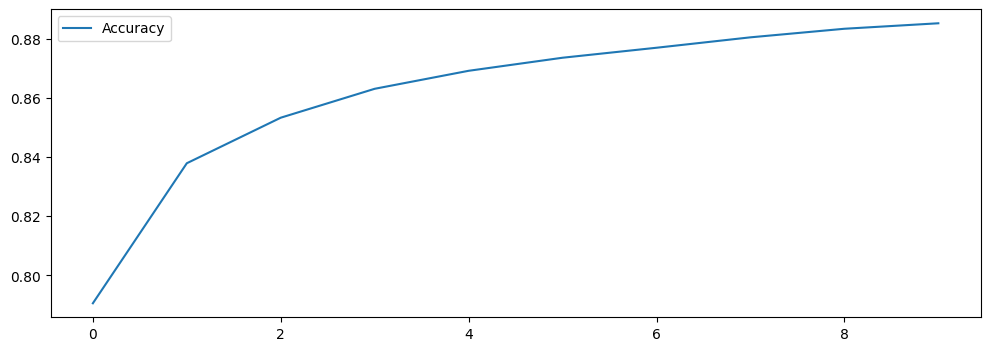

In [229]:
plt.figure(figsize=(12,4))
plt.plot(history_7.history['accuracy'], label='Accuracy')
plt.legend()

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

The final model outperformed both the baseline and the initial CNN model. By implementing early stopping, we were able to achieve the highest accuracy while avoiding overfitting. The improvements came from several key changes: we added multiple convolutional layers, applied L2 regularization to the dense layer, and maintained a dropout rate of 0.5 to improve generalization.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.